# From truck temperature to effective age at receipt (τ_in)

**Blog angle:** the cold chain sets how much biological clock has elapsed before fruit
hits the DC — not just calendar days in transit.

We integrate a Q₁₀ (Arrhenius-style) temperature response along measured pallet
temperature paths from Abdella et al. (2021), then read off **effective arrival age**
τ_in for each shipment. That discrete mix becomes the simulator's arrival-age
bootstrap (MOD-21) and the cold-chain prior in the filter.

This notebook is exploratory narrative for the blog; production logic lives in
`blueberries_voi.model.abdella` and `blueberries_voi.model.abdella_product`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.filter.arrival_priors import (
    F2A_TRANSIT_UNCERTAINTY_SD,
    cold_abdella_arrival_age_prior,
)
from blueberries_voi.filter.types import age_grid
from blueberries_voi.model import ModelParams
from blueberries_voi.model.abdella import (
    ABDELLA_PUBLISHED_DURATIONS_D,
    ShipmentTrace,
    arrival_age_from_path,
    default_abdella_root,
    load_abdella_shipments,
    shipment_arrival_age,
)
from blueberries_voi.model.abdella_product import (
    DEFAULT_DERIVED_ABDELLA_PATH,
    load_derived_abdella_arrival_ages,
)
from blueberries_voi.model.constitutive import q10_age_increment
from blueberries_voi.sim import generate_arrival_age
from blueberries_voi.rng import STREAM_ARRIVAL_SENSOR, STREAM_ARRIVAL_SHIP, spawn_rng

SEED = 42
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (9, 4.5),
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)

params = ModelParams()
print(
    f"ModelParams: q10={params.q10}, t_ref={params.t_ref_c}°C, "
    f"t_store={params.t_store_c}°C (in-store reference only)"
)

ModelParams: q10=3.0, t_ref=0.0°C, t_store=4.0°C (in-store reference only)


## Load Abdella shipment traces

Six US strawberry pallet shipments with harvest-started, multi-position loggers
(Abdella, Brecht & Uysal 2021). We lot-average the nine probe positions and clip
each trace to the **published** harvest→end-of-chain duration (Table 2).

Prefer live Parquet under `data/abdella/` when available (desktop / CI with
`[data]`). Otherwise fall back to the pre-derived `.npz` product shipped inside
the wheel — same τ_in values, no pyarrow required.

In [2]:
REPO_ROOT = Path("..").resolve()
ABDELLA_DIR = REPO_ROOT / "data" / "abdella"
NPZ_PATH = DEFAULT_DERIVED_ABDELLA_PATH


def load_shipments_or_product() -> tuple[list[ShipmentTrace] | None, dict[str, np.ndarray]]:
    """Return (parquet traces, derived ages dict). One side may be empty."""
    shipments: list[ShipmentTrace] | None = None
    ages: dict[str, np.ndarray] = {}
    try:
        shipments = load_abdella_shipments(ABDELLA_DIR)
        print(f"Loaded {len(shipments)} shipments from {ABDELLA_DIR}")
    except FileNotFoundError as exc:
        print(f"Parquet unavailable ({exc}); using derived product at {NPZ_PATH}")
    for key in ("abdella_all", "short_haul", "long_haul"):
        product = load_derived_abdella_arrival_ages(NPZ_PATH, product_key=key)
        ages[key] = product.arrival_ages
    return shipments, ages


shipments, derived_ages = load_shipments_or_product()

if shipments is not None:
    for s in shipments:
        pub = ABDELLA_PUBLISHED_DURATIONS_D[s.shipment_id]
        print(
            f"  {s.shipment_id}: {s.duration_d:.2f} d in trace "
            f"(published {pub:.2f} d), {len(s.times_d)} samples"
        )
else:
    print("Derived τ_in (days effective age at receipt):")
    for key, arr in derived_ages.items():
        print(f"  {key}: {np.round(arr, 3)}")

Loaded 6 shipments from /home/oliver/blog/blueberries-voi/data/abdella
  S1: 4.60 d in trace (published 6.39 d), 664 samples
  S2: 1.90 d in trace (published 2.05 d), 275 samples
  S3: 6.24 d in trace (published 6.39 d), 900 samples
  S4: 5.35 d in trace (published 5.50 d), 771 samples
  S5: 6.51 d in trace (published 6.62 d), 939 samples
  S6: 4.08 d in trace (published 4.19 d), 589 samples


## Temperature paths T(t)

Each line is lot-mean pallet temperature along the refrigerated leg. Warm harvest
spikes before precool are **not** shown here — the loader starts the integral at
the first sample with T < 10 °C (see honesty section below).

Short-haul corridor (Florida, ~2 d calendar) is **S2**; the other five shipments
are the CA→East long-haul mix (~4–6.6 d).

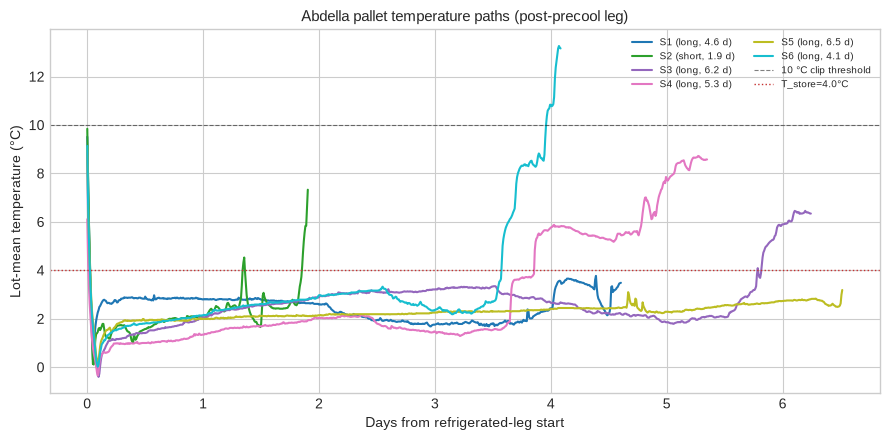

In [3]:
if shipments is None:
    print("Skipping T(t) plots — Parquet not present. Restore data/abdella/ to see paths.")
else:
    SHORT_HAUL_MAX_D = 3.0  # matches abdella_product._SHORT_HAUL_MAX_DURATION_D
    colors = plt.cm.tab10(np.linspace(0, 1, len(shipments)))

    fig, ax = plt.subplots()
    for s, c in zip(shipments, colors, strict=True):
        pub = ABDELLA_PUBLISHED_DURATIONS_D[s.shipment_id]
        haul = "short" if pub < SHORT_HAUL_MAX_D else "long"
        ax.plot(
            s.times_d,
            s.temps_c,
            label=f"{s.shipment_id} ({haul}, {s.duration_d:.1f} d)",
            color=c,
            lw=1.5,
        )
    ax.axhline(10.0, color="k", ls="--", lw=0.8, alpha=0.5, label="10 °C clip threshold")
    ax.axhline(params.t_store_c, color="#c53030", ls=":", lw=1.0, label=f"T_store={params.t_store_c}°C")
    ax.set_xlabel("Days from refrigerated-leg start")
    ax.set_ylabel("Lot-mean temperature (°C)")
    ax.set_title("Abdella pallet temperature paths (post-precool leg)")
    ax.legend(fontsize=7, ncol=2, loc="upper right")
    fig.tight_layout()
    plt.show()

## Q₁₀ integration along T(t)

Effective age advances in proportion to calendar time, scaled by a Q₁₀ factor
relative to reference temperature `t_ref`:

$$\Delta\tau = \Delta t \cdot Q_{10}^{\,(T - T_{ref})/10}$$

We use trapezoidal midpoints on each segment (`arrival_age_from_path` / `q10_age_increment`).
At constant 4 °C with Q₁₀ = 3 and T_ref = 0 °C, one calendar day ≈ 1.26 effective days —
the same factor used for in-store ageing at `t_store_c`, though transit integrates
along the **measured** path rather than a fixed store temperature.

1 calendar day at 4.0°C → 1.5518 effective days


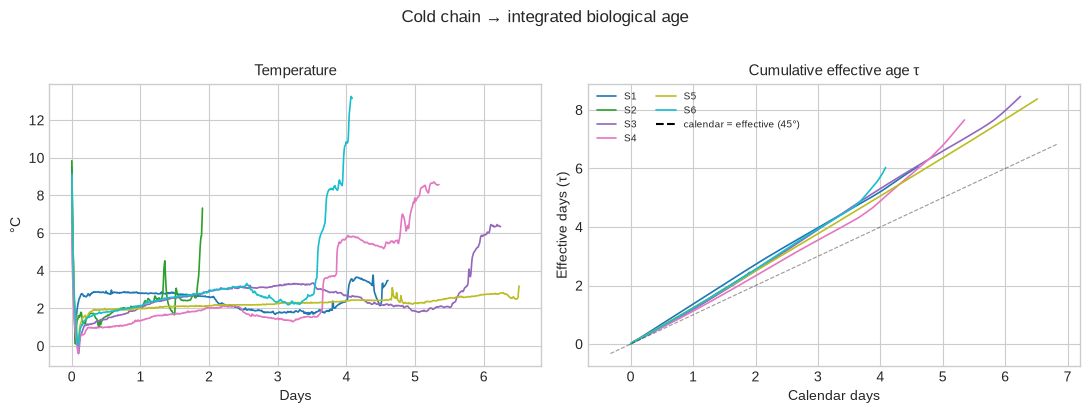

In [4]:
def cumulative_effective_age(
    temps_c: np.ndarray,
    times_d: np.ndarray,
    *,
    q10: float,
    t_ref_c: float,
) -> np.ndarray:
    """Cumulative τ along a path (same midpoint rule as shipment_arrival_age)."""
    tau = np.zeros_like(times_d, dtype=float)
    for i in range(len(times_d) - 1):
        dt = float(times_d[i + 1] - times_d[i])
        if dt <= 0:
            continue
        t_mid = 0.5 * (float(temps_c[i]) + float(temps_c[i + 1]))
        tau[i + 1] = tau[i] + q10_age_increment(
            dt, t_store_c=t_mid, t_ref_c=t_ref_c, q10=q10
        )
    return tau


# Sanity: one day at t_store should match constitutive helper.
one_day_at_store = q10_age_increment(
    1.0, t_store_c=params.t_store_c, t_ref_c=params.t_ref_c, q10=params.q10
)
print(f"1 calendar day at {params.t_store_c}°C → {one_day_at_store:.4f} effective days")

if shipments is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for s, c in zip(shipments, colors, strict=True):
        cum = cumulative_effective_age(
            s.temps_c, s.times_d, q10=params.q10, t_ref_c=params.t_ref_c
        )
        axes[0].plot(s.times_d, s.temps_c, color=c, lw=1.2)
        axes[1].plot(s.times_d, cum, color=c, lw=1.2, label=s.shipment_id)
        cal = s.times_d[-1] - s.times_d[0]
        tau_in = shipment_arrival_age(s, q10=params.q10, t_ref_c=params.t_ref_c)
        assert abs(tau_in - cum[-1]) < 1e-9
    axes[0].set_title("Temperature")
    axes[0].set_xlabel("Days")
    axes[0].set_ylabel("°C")
    axes[1].plot([], [], "k--", label="calendar = effective (45°)")
    lim = axes[1].get_xlim()
    t_line = np.linspace(lim[0], lim[1], 2)
    axes[1].plot(t_line, t_line, "k--", lw=0.8, alpha=0.4)
    axes[1].set_title("Cumulative effective age τ")
    axes[1].set_xlabel("Calendar days")
    axes[1].set_ylabel("Effective days (τ)")
    axes[1].legend(fontsize=7, ncol=2)
    fig.suptitle("Cold chain → integrated biological age", y=1.02)
    fig.tight_layout()
    plt.show()

## τ_in per shipment

**τ_in** is the total effective age at receipt — the value written onto each new
lot at delivery in the simulator. Calendar duration and τ_in diverge whenever the
pallet spends time above T_ref.

In [5]:
if shipments is not None:
    rows = []
    for s in shipments:
        cal_d = float(s.duration_d)
        tau_in = shipment_arrival_age(s, q10=params.q10, t_ref_c=params.t_ref_c)
        pub = ABDELLA_PUBLISHED_DURATIONS_D[s.shipment_id]
        rows.append(
            {
                "shipment": s.shipment_id,
                "calendar_d": cal_d,
                "published_d": pub,
                "tau_in_d": tau_in,
                "tau_over_cal": tau_in / cal_d if cal_d > 0 else np.nan,
            }
        )
    tau_table = rows
    all_tau = np.array([r["tau_in_d"] for r in rows])
else:
    all_tau = derived_ages["abdella_all"]
    tau_table = [
        {"shipment": f"S{i+1}", "tau_in_d": float(t)} for i, t in enumerate(all_tau)
    ]

print(f"{'ship':>6}  {'calendar':>9}  {'τ_in':>8}  {'τ/cal':>6}")
print("-" * 36)
for r in tau_table:
    cal = r.get("calendar_d", float("nan"))
    ratio = r.get("tau_over_cal", float("nan"))
    print(
        f"{r['shipment']:>6}  {cal:9.2f}  {r['tau_in_d']:8.3f}  {ratio:6.3f}"
    )
print(f"\nMix mean τ_in = {all_tau.mean():.3f} d  (spread {all_tau.min():.2f}–{all_tau.max():.2f} d)")

  ship   calendar      τ_in   τ/cal
------------------------------------
    S1       4.60     6.067   1.318
    S2       1.90     2.449   1.287
    S3       6.24     8.462   1.355
    S4       5.35     7.661   1.433
    S5       6.51     8.376   1.286
    S6       4.08     6.033   1.478

Mix mean τ_in = 6.508 d  (spread 2.45–8.46 d)


## Short-haul vs long-haul τ_in

MOD-21 bootstraps **all six** shipments: one Florida short corridor (~2 d) plus
five CA→East long corridors (~4–6.6 d). That bimodal calendar spread becomes
a spread in τ_in — the identification signal for "transit dominates" in FIL-11.

Product keys in `abdella_arrival_ages.npz`:
- `short_haul` — published duration < 3 d (S2 only)
- `long_haul` — everything else
- `abdella_all` — full mix

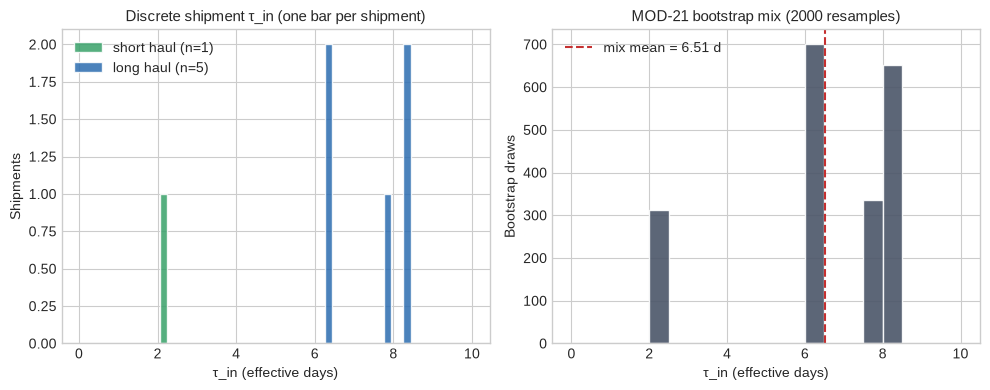

short haul: τ_in = [2.44874108]  |  long haul mean = 7.32 d (range 6.03–8.46)


In [6]:
short_tau = derived_ages["short_haul"]
long_tau = derived_ages["long_haul"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = np.linspace(0, 10, 21)

axes[0].hist(
    [short_tau, long_tau],
    bins=bins,
    label=[f"short haul (n={short_tau.size})", f"long haul (n={long_tau.size})"],
    color=["#38a169", "#2b6cb0"],
    edgecolor="white",
    alpha=0.85,
)
axes[0].set_xlabel("τ_in (effective days)")
axes[0].set_ylabel("Shipments")
axes[0].set_title("Discrete shipment τ_in (one bar per shipment)")
axes[0].legend()

# Bootstrap-style histogram: resample shipments with replacement (simulator mix).
n_boot = 2000
boot = rng.choice(all_tau, size=n_boot, replace=True)
axes[1].hist(boot, bins=bins, color="#4a5568", edgecolor="white", alpha=0.9)
axes[1].axvline(all_tau.mean(), color="#c53030", ls="--", label=f"mix mean = {all_tau.mean():.2f} d")
axes[1].set_xlabel("τ_in (effective days)")
axes[1].set_ylabel("Bootstrap draws")
axes[1].set_title("MOD-21 bootstrap mix (2000 resamples)")
axes[1].legend()

fig.tight_layout()
plt.show()

print(
    f"short haul: τ_in = {short_tau}  |  long haul mean = {long_tau.mean():.2f} d "
    f"(range {long_tau.min():.2f}–{long_tau.max():.2f})"
)

---

## Honesty: what we are (and are not) claiming

### Strawberry loggers → blueberry kinetics (MOD-23)

The temperature **paths** come from Abdella's **strawberry** pallets. Spoilage
kinetics (η_ref, β, Q₁₀) are calibrated for **blueberries** (UC Davis). We borrow
only the thermal-path ensemble; species differ in respiration and shelf life.

> *Accepted substitution (ADR 0045): one-sentence appendix caveat. Revisit if an
> open blueberry pallet-logger dataset of comparable resolution appears.*

The blog should show real T(t) curves while being explicit that τ_in is
"strawberry truck, blueberry clock."

### T < 10 °C clip (start of refrigerated leg)

Warm harvest spikes before precool can dominate the Arrhenius integral and push τ_in
far above the FIL-15 grid [0, 8] days. The loader therefore **starts integration at
the first lot-mean sample below 10 °C**, not at harvest.

This is a modelling choice documented in `data/abdella/PROVENANCE.md` — not a
claim that fruit was biologically inactive above 10 °C.

### `spread_scale` (FIL-11 contrast knob)

The open-loop simulator can **shrink** arrival-age dispersion toward the mix mean
without changing code paths:

```
τ_sample = mean(τ_shipments) + spread_scale × (τ_drawn − mean)
```

`spread_scale = 1` preserves the full Abdella bootstrap; values `< 1` tighten the
prior for Stage A "what if transit were less variable?" experiments. This is a
**diagnostic**, not a calibrated estimate of real-world transit spread.

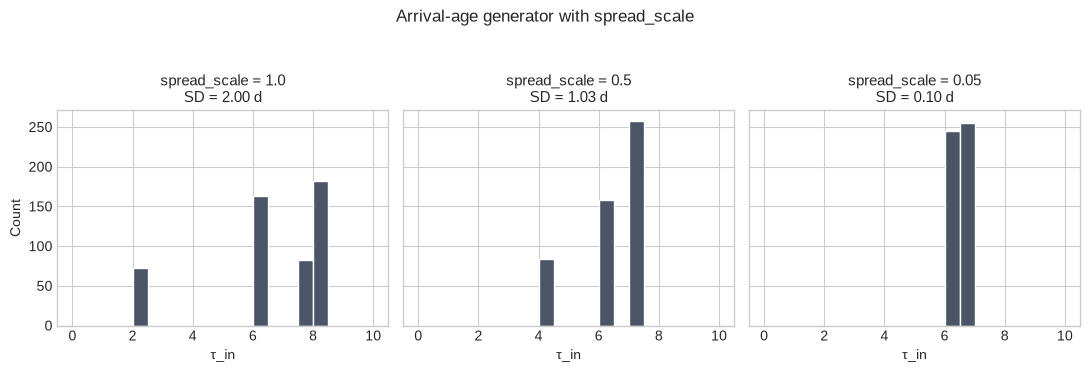

In [7]:
if shipments is None:
    print("spread_scale demo needs Parquet traces; skipping.")
else:
    rng_ship = spawn_rng(
        SEED, run_id="nb02", day=0, stream=STREAM_ARRIVAL_SHIP
    )
    rng_sensor = spawn_rng(
        SEED, run_id="nb02", day=0, stream=STREAM_ARRIVAL_SENSOR
    )
    n_draws = 500
    scales = [1.0, 0.5, 0.05]
    fig, axes = plt.subplots(1, len(scales), figsize=(11, 3.5), sharey=True)
    for ax, scale in zip(axes, scales, strict=True):
        draws = [
            generate_arrival_age(
                rng_ship, rng_sensor, shipments, params, spread_scale=scale
            )
            for _ in range(n_draws)
        ]
        ax.hist(draws, bins=bins, color="#4a5568", edgecolor="white")
        sd = float(np.std(draws))
        ax.set_title(f"spread_scale = {scale}\nSD = {sd:.2f} d")
        ax.set_xlabel("τ_in")
    axes[0].set_ylabel("Count")
    fig.suptitle("Arrival-age generator with spread_scale", y=1.05)
    fig.tight_layout()
    plt.show()

### `F2A_TRANSIT_UNCERTAINTY_SD = 0.75` (uncalibrated)

When the filter sees an ASN **pack date** (SCN-F2a) but not full age at receipt,
it places a Gaussian prior on τ_in with standard deviation **0.75 effective days**.
That width is a **documented default** chosen so F2a is narrower than the cold
Abdella mix — not a fitted transit model.

Compare the discrete cold mix SD to the F2a Gaussian below.

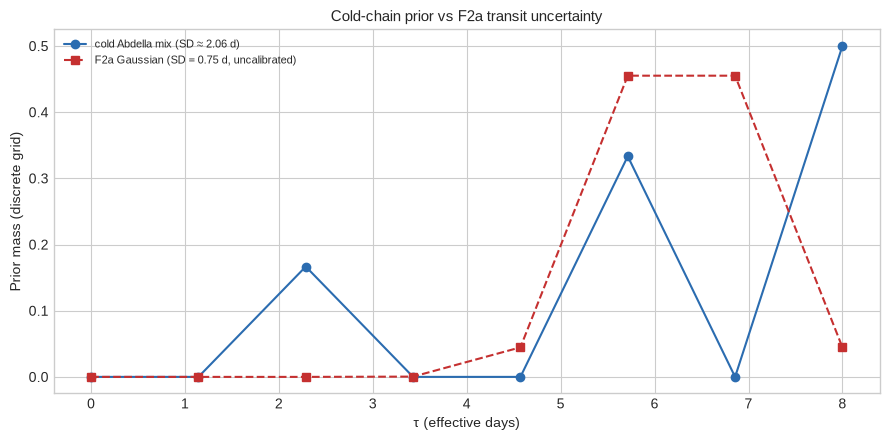

cold mix SD ≈ 2.060 d
F2A_TRANSIT_UNCERTAINTY_SD = 0.75 d  (module constant, not fitted)
F2a narrower? True


In [8]:
K = 8  # production age grid
grid = age_grid(K)
cold_prior = cold_abdella_arrival_age_prior(grid, params)


def prior_sd(prior: np.ndarray, grid: np.ndarray) -> float:
    mean = float(np.sum(grid * prior))
    var = float(np.sum(prior * (grid - mean) ** 2))
    return float(np.sqrt(max(var, 0.0)))


cold_sd = prior_sd(cold_prior, grid)
f2a_sd = F2A_TRANSIT_UNCERTAINTY_SD

fig, ax = plt.subplots()
ax.plot(grid, cold_prior, "o-", label=f"cold Abdella mix (SD ≈ {cold_sd:.2f} d)", color="#2b6cb0")
mean_cold = float(np.sum(grid * cold_prior))
f2a_curve = np.exp(-0.5 * ((grid - mean_cold) / f2a_sd) ** 2)
f2a_curve /= f2a_curve.sum()
ax.plot(
    grid,
    f2a_curve,
    "s--",
    color="#c53030",
    label=f"F2a Gaussian (SD = {f2a_sd} d, uncalibrated)",
)
ax.set_xlabel("τ (effective days)")
ax.set_ylabel("Prior mass (discrete grid)")
ax.set_title("Cold-chain prior vs F2a transit uncertainty")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"cold mix SD ≈ {cold_sd:.3f} d")
print(f"F2A_TRANSIT_UNCERTAINTY_SD = {f2a_sd} d  (module constant, not fitted)")
print(f"F2a narrower? {f2a_sd < cold_sd}")

---

## Takeaways for the blog post

1. **Cold chain → τ_in:** measured truck temperatures, integrated with blueberry Q₁₀,
   set how "old" fruit is at receipt — often *older* than calendar transit time.
2. **Mix matters:** one short-haul and five long-haul shipments create spread in τ_in
   that downstream filter experiments depend on.
3. **Caveats up front:** strawberry paths, 10 °C start clip, `spread_scale` as a
   sensitivity knob, and F2a SD = 0.75 d as an uncalibrated filter default.

Next notebook in the series can connect this arrival prior to in-store spoilage
and the value-of-information ladder.